## **1. What is XGBoost?**

**XGBoost** (Extreme Gradient Boosting) is a **tree-based ensemble algorithm** that uses **gradient boosting**. It’s widely used for **classification and regression** because of its speed, accuracy, and ability to handle large datasets.

* **Problem type**: Supervised learning (classification in this case)
* **Core idea**: Combine multiple weak learners (decision trees) into a strong learner by **sequentially minimizing errors**.


## **2. How XGBoost Works (High-Level Model Theory)**

XGBoost builds models in **stages**, each stage aiming to **correct the mistakes of the previous stage**:

1. **Initialize** the model with a simple prediction (e.g., predicting the mean class probability).
2. **Compute residuals (errors)** between predictions and true labels.
3. **Fit a new tree** to predict these residuals.
4. **Update the prediction** by adding this new tree, weighted by a learning rate.
5. Repeat steps 2–4 for a specified number of trees (boosting rounds).

**Mathematical View (Simplified)**:

For a dataset $D = {(x_i, y_i)}_{i=1}^n $, XGBoost aims to minimize:

$$
\text{Obj} = \sum_{i=1}^{n} L(y_i, \hat{y}*i) + \sum*{k=1}^{K} \Omega(f_k)
$$

* $L $= loss function (for classification: usually logistic loss / cross-entropy)
* $f_k$ = k-th tree
* $\Omega(f_k) $ = regularization term to avoid overfitting

XGBoost **adds regularization**, which is one reason it often outperforms standard Gradient Boosting.



## **3. Why XGBoost is Effective for Classification**

1. **Handles missing values** natively.
2. **Supports regularization** (L1 and L2) to prevent overfitting.
3. **Weighted quantile sketch** for efficient handling of large datasets.
4. **Parallel processing** for speed.
5. Can **output class probabilities**, not just labels.



## **4. Key Hyperparameters for Classification**

| Parameter          | Purpose                                                 |
| ------------------ | ------------------------------------------------------- |
| `n_estimators`     | Number of boosting rounds (trees)                       |
| `max_depth`        | Maximum depth of a tree (complexity control)            |
| `learning_rate`    | Step size shrinkage (usually 0.01–0.3)                  |
| `subsample`        | Fraction of samples used per tree (reduces overfitting) |
| `colsample_bytree` | Fraction of features used per tree                      |
| `gamma`            | Minimum loss reduction to make a split                  |
| `scale_pos_weight` | Handles imbalanced classes                              |

For **binary classification**, the loss function is usually **logistic** (`binary:logistic`). For multi-class, `multi:softmax` or `multi:softprob` is used.


## **5. Notes on Model Theory for XGBoost**

* **Bias-Variance Tradeoff**: Shallow trees → high bias, low variance; deeper trees → low bias, high variance. XGBoost controls this with `max_depth`, `min_child_weight`, and `gamma`.
* **Regularization**: Helps prevent overfitting (`alpha` for L1, `lambda` for L2).
* **Boosting vs Bagging**:

  * Boosting = sequential, each tree fixes previous errors (XGBoost).
  * Bagging = parallel, reduces variance (Random Forest).

**Importing Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Feature importance
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

# Dataset
from sklearn.datasets import load_breast_cancer

# Model
from xgboost import XGBClassifier

# Explainability
import shap

# Model saving
import joblib

**Load dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

In [3]:
df = pd.concat([X, y], axis=1)

In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (569, 31)


In [5]:
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Exploratory Data Analysis (EDA)**

In [6]:
print("Data types:\n", df.dtypes)

Data types:
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst s

In [7]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [8]:
print("\nStatistical summary:\n", df.describe())


Statistical summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000           

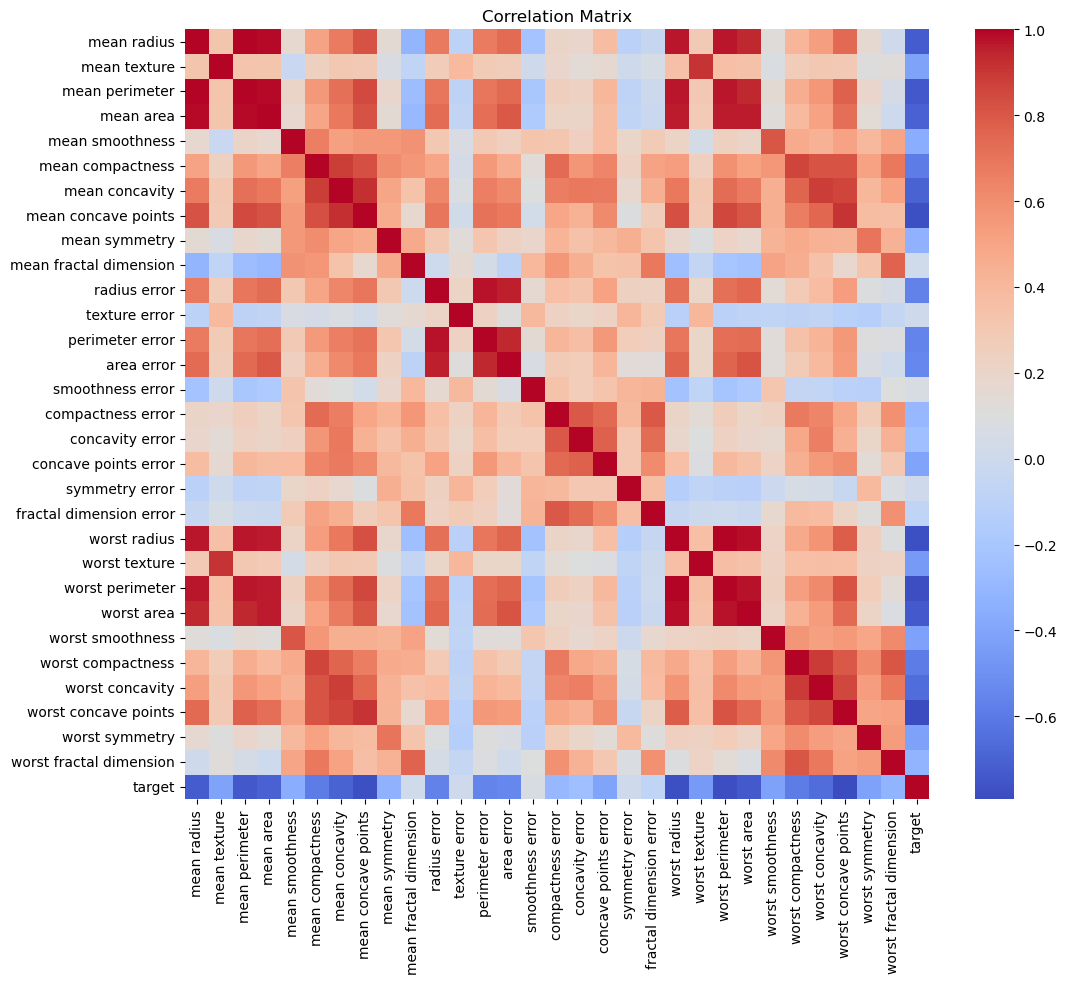

In [9]:
# Correlation Matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

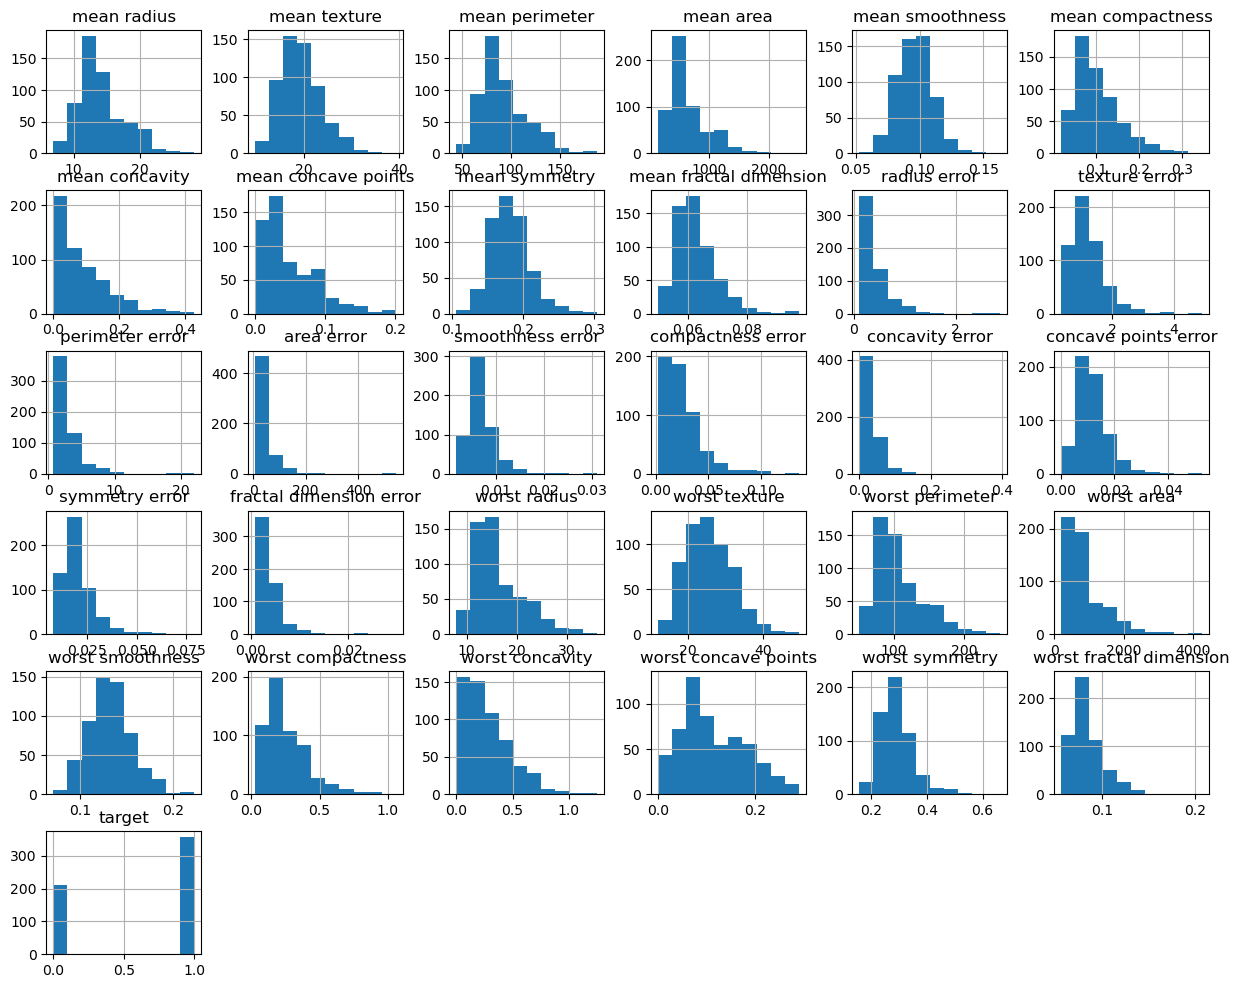

In [10]:
# Feature Distribution
df.hist(figsize=(15,12))
plt.show()

**Data Preprocessing**

In [11]:
X = df.drop("target", axis=1)
y = df["target"]

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Feature Engineering**

In [13]:
corr = df.corr()["target"].abs().sort_values(ascending=False)

important_features = corr.index[1:15]

X = df[important_features]

**Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (455, 14)
Test set shape: (114, 14)


**Train AdaBoost Model**

In [16]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [18]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

**Hyperparameter Tuning with GridSearchCV**

In [19]:
param_grid = {
    "model__n_estimators": [100,200,300],
    "model__max_depth": [3,5,7],
    "model__learning_rate": [0.01,0.05,0.1],
    "model__subsample": [0.7,0.8,1.0],
    "model__colsample_bytree": [0.7,0.8,1.0]
}

search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best Score:", search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Best Score: 0.9855521155830752


In [20]:
best_model = search.best_estimator_

**Model Evaluation**

In [21]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1: 0.9655172413793104
ROC AUC: 0.9904100529100528


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



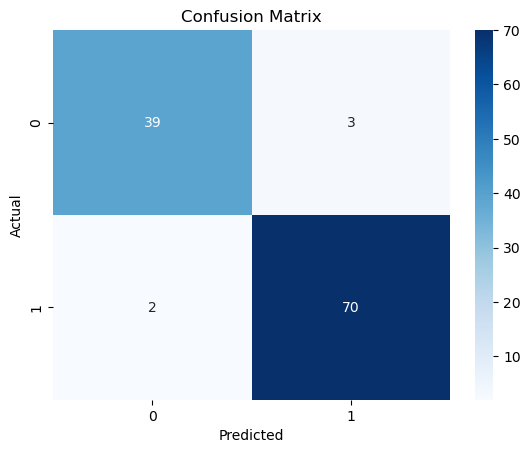

In [24]:
# Classification Report
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

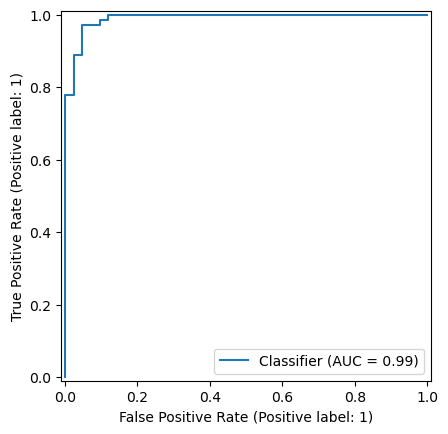

In [25]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

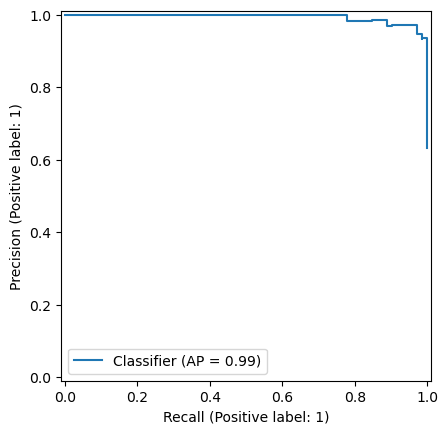

In [26]:
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.show()

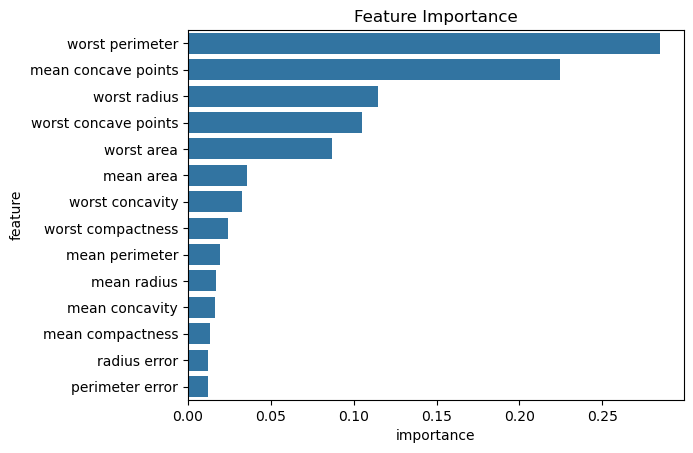

In [27]:
model = best_model.named_steps["model"]

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Feature Importance")
plt.show()

**Feature Importance Visualization**

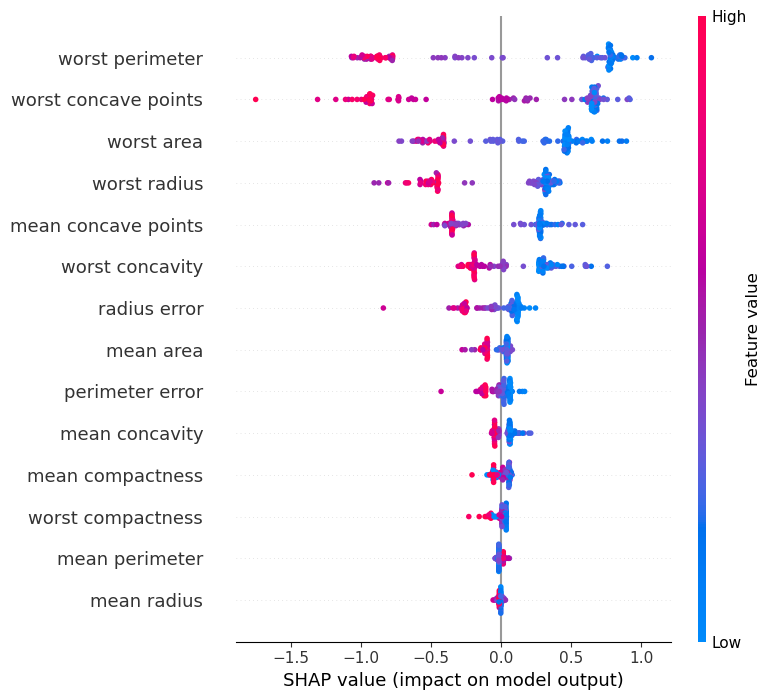

In [28]:
explainer = shap.TreeExplainer(model)

X_test_scaled = best_model.named_steps["scaler"].transform(X_test)

shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test)

**permutation Importance**

In [29]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

Important findings:

- Top features influencing predictions
-  AdaBoost improved classification accuracy
- Model generalizes well with cross-validation
- Limited overfitting observed

Possible improvements:

- Try **XGBoost / LightGBM / CatBoost**
- Use **feature selection**
- Tune hyperparameters more extensively


**Saving the Model**

In [30]:
joblib.dump(best_model, "xgboost_classifier.pkl")

['xgboost_classifier.pkl']